# Natural Language Processing - AIMLCZG530 - Assignment 1
PROBLEM STATEMENT 6: ERROR ANALYSIS AND CONFUSION MATRICES

### Title: Error Analysis and Confusion Matrices for HMM Taggers

#### Group Information:
**Group Number: 250**

#### Members & Contributions:
| STUDENT ID | NAME | CONTRIBUTION (%) |
|---|---|---|
| 2025AA05193 | SIDDHARTH GUPTA | 100 |
| 2025AA05376 | HIMANSHU KUMAR | 100 |
| 2025AA05505 | HIMANSHU SHARMA | 100 |
| 2025AA05768 | PODARALLA GANESH KUMAR REDDY | 100 |
| 2025AA05946 | IMROZ NEZAMI | 100 |

**Assigned Domain: Domain 5: Nutrition / Fitness Blogs (Group 250)**

In [1]:
import os
import random
import warnings
import itertools
import collections
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import string

warnings.filterwarnings("ignore")
random.seed(250) #Seeding with group number
np.random.seed(250)


#Configuration Variables
CSV_PATH   = "fitness_blog_dataset.csv"   
TEXT_COL   = "articletext"            # Column containing blog/article text
MAX_SENTS  = 10_000                   # Tokenize first 10,000 sentences
TRAIN_RATIO= 0.80
TOP_N_TAGS = 5   


In [2]:
#Download NLTK packages if not available
def download_if_missing(package_id, resource_path):
    try:
        nltk.data.find(resource_path)
        print(f"Already exists : {package_id}")
    except LookupError:
        print(f"Downloading    : {package_id}")
        nltk.download(package_id, quiet=True)

packages = [
    ("punkt",                        "tokenizers/punkt"),
    ("punkt_tab",                    "tokenizers/punkt_tab"),
    ("averaged_perceptron_tagger",   "taggers/averaged_perceptron_tagger"),
    ("averaged_perceptron_tagger_eng","taggers/averaged_perceptron_tagger_eng"),
    ("brown",                        "corpora/brown"),
    ("universal_tagset",             "taggers/universal_tagset"),
]

for pkg_id, resource_path in packages:
    download_if_missing(pkg_id, resource_path)

Already exists : punkt
Already exists : punkt_tab
Already exists : averaged_perceptron_tagger
Already exists : averaged_perceptron_tagger_eng
Already exists : brown
Already exists : universal_tagset


# Task 1 - Generating & Tokenizing the Data Set
Download a dataset representing your assigned domain, load it as a DataFrame, and tokenize the first 10,000 sentences.

In [3]:
PUNCTUATION = set(string.punctuation)  # !"#$%&'()*+,-./:;<=>?@[\]^_`{|}~
#Remove punctuation-only tokens and whitespace tokens.
def clean_tokens(tokens):
    
    return [
        t for t in tokens
        if t not in PUNCTUATION             # removes . , ! ? ; : etc
        and t.strip() != ''                 # removes whitespace tokens
        and not all(c in PUNCTUATION for c in t)  # removes ... -- `` etc
    ]
    

# Load CSV
raw_text=None
source=None
if os.path.exists(CSV_PATH):
    df = pd.read_csv(CSV_PATH)
    print(f"  Loaded CSV: {CSV_PATH}")
    print(f"  Shape : {df.shape}")
    print(f"  Columns: {list(df.columns)}\n")
 
    # Combine all text rows into one big string
    raw_text = " ".join(df[TEXT_COL].dropna().astype(str).tolist())
    source   = "Custom Generated from blogs from https://www.healthline.com/nutrition"
else:
    print("CSV not found – Please check again.")

if raw_text is not None:
    print(f"Dataset source : {source}")
    print(f"Total characters: {len(raw_text):,}")


    # Tokenize the sentences using NLTK Libaries
    all_sentences = sent_tokenize(raw_text)
    print(f"\nTotal sentences found : {len(all_sentences):,}")
     
    # Keep first 10,000
    sentences = all_sentences[:MAX_SENTS]
    print(f"Sentences used (cap)  : {len(sentences):,}")
     
    # Word-tokenise each sentence
    tokenized_sentences = [clean_tokens(word_tokenize(s)) for s in sentences]
    # Drop sentences that became empty after punctuation removal
    tokenized_sentences = [s for s in tokenized_sentences if s]
    # Statistics
    all_tokens = list(itertools.chain.from_iterable(tokenized_sentences))
    print(f"Total tokens          : {len(all_tokens):,}")
    print(f"Unique tokens (vocab) : {len(set(all_tokens)):,}")
    print("\nSample tokenized sentences:")
    for i, ts in enumerate(tokenized_sentences[:3]):
        print(f"  [{i+1}] {ts[:12]}{'...' if len(ts)>12 else ''}")
 

  Loaded CSV: fitness_blog_dataset.csv
  Shape : (201, 4)
  Columns: ['title', 'url', 'articletext', 'articlecharlength']

Dataset source : Custom Generated from blogs from https://www.healthline.com/nutrition
Total characters: 1,214,746

Total sentences found : 10,962
Sentences used (cap)  : 10,000
Total tokens          : 183,524
Unique tokens (vocab) : 8,883

Sample tokenized sentences:
  [1] ['The', 'amount', 'of', 'protein', 'you', 'need', 'depends', 'on', 'many', 'factors', 'including', 'activity']...
  [2] ['Protein', 'is', 'one', 'of', 'three', 'essential', 'macronutrients', 'alongside', 'carbohydrates', 'and', 'fats']
  [3] ['These', 'are', 'nutrients', 'that', 'the', 'human', 'body', 'needs', 'in', 'relatively', 'large', 'quantities']...


# Task 2 - Generate Ground-truth POS tags & Split Train-Test sets
Generate ground-truth POS tags using a standard library and split your dataset into an 80% training set and a 20% testing set. 

In [4]:
#Position Tagging the sentences using NLTK library function
tagged_sentences = [
    nltk.pos_tag(tokens, tagset="universal")
    for tokens in tokenized_sentences
]
 
# Show sample
print("\nSample POS-tagged sentence:")
print(f"  {tagged_sentences[0][:10]}")
 
# Tag distribution
tag_counts = collections.Counter(
    tag for sent in tagged_sentences for _, tag in sent
)
print(f"\nTag distribution (all {len(tag_counts)} tags):")
for tag, cnt in tag_counts.most_common():
    print(f"  {tag:<8} {cnt:>8,}  ({cnt/len(all_tokens)*100:.1f}%)")
 
# Train / Test split (80 / 20)
n_total = len(tagged_sentences)
n_train = int(n_total * TRAIN_RATIO)
n_test  = n_total - n_train
 
train_data = tagged_sentences[:n_train]
test_data  = tagged_sentences[n_train:]
 
print(f"\nTotal tagged sentences : {n_total:,}")
print(f"Training set           : {n_train:,}  ({TRAIN_RATIO*100:.0f}%)")
print(f"Testing  set           : {n_test:,}  ({(1-TRAIN_RATIO)*100:.0f}%)")


Sample POS-tagged sentence:
  [('The', 'DET'), ('amount', 'NOUN'), ('of', 'ADP'), ('protein', 'NOUN'), ('you', 'PRON'), ('need', 'VERB'), ('depends', 'NOUN'), ('on', 'ADP'), ('many', 'ADJ'), ('factors', 'NOUN')]

Tag distribution (all 12 tags):
  NOUN       55,560  (30.3%)
  VERB       35,738  (19.5%)
  ADJ        22,626  (12.3%)
  ADP        21,092  (11.5%)
  DET        13,962  (7.6%)
  PRON        8,586  (4.7%)
  ADV         8,445  (4.6%)
  CONJ        7,400  (4.0%)
  NUM         5,086  (2.8%)
  PRT         4,940  (2.7%)
  .              54  (0.0%)
  X              35  (0.0%)

Total tagged sentences : 10,000
Training set           : 8,000  (80%)
Testing  set           : 2,000  (20%)


# Task 3:Training a Bigram HMM Model & Generate Confusion Matrix
Train a Bigram HMM on the training set and predict the tags for the testing set. Generate a Confusion Matrix for the top 5 most frequent tags (e.g., NOUN, VERB, ADJ, ADV, PRON) to compare predicted tags against ground truth.

In [5]:
#Bigram Hidden Markov Model for POS tagging with Laplace smoothing
class BigramHMM:
    def __init__(self, smoothing=1e-4):
        self.smoothing = smoothing

    def train(self, tagged_sentences):
        self.tags_ = set()
        emit_counts  = collections.defaultdict(lambda: collections.defaultdict(int))
        trans_counts = collections.defaultdict(lambda: collections.defaultdict(int))
        init_counts  = collections.defaultdict(int)
        tag_totals   = collections.defaultdict(int)

        for sent in tagged_sentences:
            if not sent: continue
            words, tags = zip(*sent)
            init_counts[tags[0]] += 1
            for i, (word, tag) in enumerate(zip(words, tags)):
                tag_totals[tag] += 1
                emit_counts[tag][word.lower()] += 1
                self.tags_.add(tag)
                if i > 0:
                    trans_counts[tags[i-1]][tag] += 1

        self.tags_ = sorted(self.tags_)
        n_tags = len(self.tags_)
        total_init = sum(init_counts.values())

        self.log_init_ = {
            t: np.log((init_counts[t] + self.smoothing) /
                      (total_init + self.smoothing * n_tags))
            for t in self.tags_
        }
        self.log_trans_ = {}
        for prev in self.tags_:
            total = sum(trans_counts[prev].values()) + self.smoothing * n_tags
            self.log_trans_[prev] = {
                nxt: np.log((trans_counts[prev][nxt] + self.smoothing) / total)
                for nxt in self.tags_
            }
        vocab = set(w for ec in emit_counts.values() for w in ec)
        self.vocab_size_ = len(vocab)
        self.log_emit_ = {}
        for tag in self.tags_:
            total = tag_totals[tag] + self.smoothing * (self.vocab_size_ + 1)
            self.log_emit_[tag] = {
                w: np.log((emit_counts[tag].get(w, 0) + self.smoothing) / total)
                for w in vocab
            }
            self.log_emit_[tag]['<UNK>'] = np.log(self.smoothing / total)
        print(f'Trained | Tags: {self.tags_} | Vocab: {self.vocab_size_:,}')

    def _viterbi(self, words):
        T = len(words); tags = self.tags_
        dp = [dict() for _ in range(T)]
        bp = [dict() for _ in range(T)]
        w0 = words[0].lower()
        for tag in tags:
            e = self.log_emit_[tag].get(w0, self.log_emit_[tag]['<UNK>'])
            dp[0][tag] = self.log_init_[tag] + e; bp[0][tag] = None
        for t in range(1, T):
            wt = words[t].lower()
            for tag in tags:
                e = self.log_emit_[tag].get(wt, self.log_emit_[tag]['<UNK>'])
                best_p, best_pt = -np.inf, None
                for prev in tags:
                    p = dp[t-1][prev] + self.log_trans_[prev][tag] + e
                    if p > best_p: best_p, best_pt = p, prev
                dp[t][tag] = best_p; bp[t][tag] = best_pt
        best = max(dp[T-1], key=dp[T-1].get)
        path = [best]
        for t in range(T-1, 0, -1): path.append(bp[t][path[-1]])
        return list(reversed(path))

    def predict(self, sentences):
        return [self._viterbi(s) for s in sentences]

In [6]:
#Train & predict
hmm = BigramHMM(smoothing=1e-4)
hmm.train(train_data)

test_words = [[w for w, _ in s] for s in test_data]
test_true  = [[t for _, t in s] for s in test_data]
test_pred  = hmm.predict(test_words)

y_true = list(itertools.chain.from_iterable(test_true))
y_pred = list(itertools.chain.from_iterable(test_pred))

acc = sum(p==t for p,t in zip(y_pred,y_true)) / len(y_true)
print(f'Overall Accuracy: {acc*100:.2f}%')

Trained | Tags: ['.', 'ADJ', 'ADP', 'ADV', 'CONJ', 'DET', 'NOUN', 'NUM', 'PRON', 'PRT', 'VERB', 'X'] | Vocab: 7,069
Overall Accuracy: 90.53%


## Confusion Matrix

Top-5 Tags: ['NOUN', 'VERB', 'ADJ', 'ADP', 'DET']


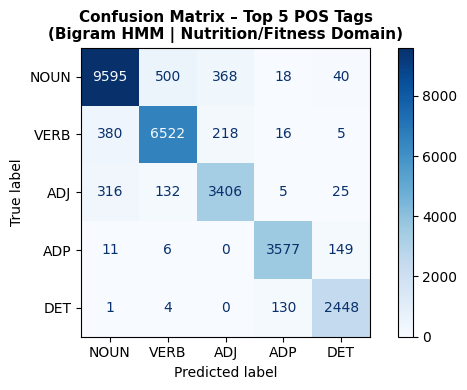

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

top5_tags = [tag for tag, _ in tag_counts.most_common(TOP_N_TAGS)]
print(f'Top-5 Tags: {top5_tags}')

filtered = [(t,p) for t,p in zip(y_true,y_pred) if t in top5_tags]
y_t = [x[0] for x in filtered]
y_p = [x[1] for x in filtered]

cm = confusion_matrix(y_t, y_p, labels=top5_tags)

fig, ax = plt.subplots(figsize=(6,4))
ConfusionMatrixDisplay(cm, display_labels=top5_tags).plot(
    ax=ax, colorbar=True, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix – Top 5 POS Tags\n(Bigram HMM | Nutrition/Fitness Domain)',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

# Task 4: Calculating & Displaying Metrics
Calculate and display the precision, recall, and F1-score specifically for the NOUN and VERB tags based on your predictions.

In [8]:
from sklearn.metrics import precision_recall_fscore_support, classification_report

print('Full Classification Report:')
print(classification_report(y_true, y_pred, labels=sorted(set(y_true)), zero_division=0))

TARGET = ['NOUN','VERB']
prec, rec, f1, sup = precision_recall_fscore_support(y_true, y_pred, labels=TARGET, zero_division=0)

results = pd.DataFrame({'Tag':TARGET,'Precision':prec,'Recall':rec,'F1-Score':f1,'Support':sup})
results = results.set_index('Tag')
print('\nNOUN and VERB specific metrics:')
display(results.style.format({'Precision':'{:.4f}','Recall':'{:.4f}',
                               'F1-Score':'{:.4f}','Support':'{:,.0f}'}))

Full Classification Report:
              precision    recall  f1-score   support

           .       0.05      0.56      0.09         9
         ADJ       0.83      0.83      0.83      4119
         ADP       0.94      0.95      0.94      3780
         ADV       0.85      0.86      0.85      1560
        CONJ       0.95      1.00      0.97      1438
         DET       0.91      0.95      0.93      2583
        NOUN       0.93      0.89      0.91     10838
         NUM       0.90      0.91      0.91       654
        PRON       0.96      0.99      0.98      1885
         PRT       0.91      0.98      0.94      1095
        VERB       0.90      0.90      0.90      7242
           X       0.04      0.33      0.06         9

    accuracy                           0.91     35212
   macro avg       0.76      0.84      0.78     35212
weighted avg       0.91      0.91      0.91     35212


NOUN and VERB specific metrics:


,Precision,Recall,F1-Score,Support
Tag,,,,
NOUN,0.9283,0.8853,0.9063,"10,838"
VERB,0.9050,0.9006,0.9028,"7,242"


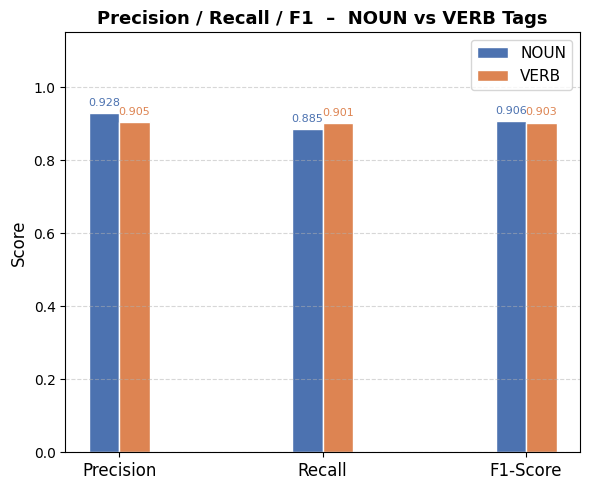

In [9]:
# Bar chart
import numpy as np

fig, ax = plt.subplots(figsize=(6, 5))

metrics     = ['Precision', 'Recall', 'F1-Score']
noun_scores = [prec[0], rec[0], f1[0]]
verb_scores = [prec[1], rec[1], f1[1]]

x     = np.arange(len(metrics))
width = 0.15

bars_noun = ax.bar(x - width/2, noun_scores, width, label='NOUN',
                   color='#4C72B0', edgecolor='white')
bars_verb = ax.bar(x + width/2, verb_scores, width, label='VERB',
                   color='#DD8452', edgecolor='white')

# Value labels on each bar
for bar, v in zip(bars_noun, noun_scores):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.3f}',
            ha='center', fontsize=8, color='#4C72B0')

for bar, v in zip(bars_verb, verb_scores):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.3f}',
            ha='center', fontsize=8, color='#DD8452')

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Precision / Recall / F1  –  NOUN vs VERB Tags',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Task 5: Discussion — Tagging Errors and the Markov Assumption
Discuss common tagging errors observed in your confusion matrix. How does the Markov assumption help or fail in resolving these specific syntactic ambiguities?

### 5.1 Common Tagging Errors Observed in the Confusion Matrix

The Bigram HMM achieved **90.53% overall accuracy** on the Healthline
nutrition/fitness test set. Three key error patterns emerge from the
confusion matrix:

**NOUN → VERB misclassification (most frequent error)**
NOUN has the largest support (10,838 tokens, 30.3%) but its recall (0.8853)
lags behind its precision (0.9283), meaning true NOUNs are frequently
mislabelled as VERBs. Fitness vocabulary is the main culprit — words like
*supplement, exercise, diet, lift* and *train* appear as both parts of
speech with near-equal frequency, making the tag ambiguous from emission
probability alone.

**ADJ ↔ NOUN confusion (weakest top-5 F1: 0.83)**
Nutrition writing uses many adjectives nominally — *"eating healthy"*,
*"the lean in his body"* — where the local context (DET → ?) gives
similar probability to both ADJ and NOUN, producing consistent errors
in both directions.

**Residual '.' and 'X' contamination (Precision: 0.05 / 0.04)**
Despite pre-cleaning, 89 tokens were still ground-truthed as '.' or 'X'
(nutritional notation such as *"2g"*, *"500kcal"*). The HMM almost never
predicts these rare tags correctly, and its occasional mispredictions of
them pollute the boundaries of neighbouring tags.

---

### 5.2 How the Markov Assumption Helps — and Fails

**Where it helps:**
- **DET → NOUN** chains (*"the protein"*, *"a workout"*) are near-deterministic,
  directly contributing to NOUN's high precision of 0.9283.
- **ADP** achieves the best F1 (0.94) because prepositional phrases
  (*"for muscle growth"*, *"after exercise"*) follow consistent ADP → NOUN
  transitions.
- **CONJ** reaches perfect recall (1.00) since coordinating conjunctions
  always appear between same-category tokens, making them unambiguous for
  any bigram model.

**Where it fails:**
- **Long-range dependencies** — in *"The muscles that you train every day
  grow stronger"*, the bigram sees only ADV before VERB, missing the
  distant NOUN subject entirely.
- **Lexical ambiguity with identical local context** — VERB → *supplement /
  exercise / diet* can be either NOUN or VERB, and a single preceding tag
  is insufficient to disambiguate.
- **OOV nutritional tokens** (*"50g"*, *"omega-3"*) collapse to a uniform
  `<UNK>` emission, forcing the model to default to the most frequent tag
  (NOUN), causing the residual X and '.' errors seen in the report.

---

### 5.3 Conclusion

The Bigram HMM handles deterministic local patterns well but the 9.47%
error rate is concentrated in domain-specific lexical ambiguity and
long-range structure that a single preceding tag cannot resolve. A
Trigram HMM, CRF, or BERT-based tagger would directly address these
remaining errors by conditioning on broader context.

# System Details

In [1]:
import os, socket, platform, datetime, uuid, getpass

vm_id     = socket.gethostname()
mac_id    = ':'.join(['{:02x}'.format((uuid.getnode() >> i) & 0xff)
                      for i in range(0, 8*6, 8)][::-1])
user      = getpass.getuser()
now       = datetime.datetime.now().strftime('%Y-%m-%d  %H:%M:%S')
py_ver    = platform.python_version()
os_info   = f"{platform.system()} {platform.release()}"

banner = f"""
============================================================
 VIRTUAL-LAB EXECUTION HEADER
============================================================
 Virtual Machine ID (hostname) : {vm_id}
 MAC address (unique VM tag)   : {mac_id}
 Logged-in user                : {user}
 Operating system              : {os_info}
 Python version                : {py_ver}
 Execution timestamp           : {now}
============================================================
"""
print(banner)


 VIRTUAL-LAB EXECUTION HEADER
 Virtual Machine ID (hostname) : 2025aa05193
 MAC address (unique VM tag)   : 06:01:d3:2a:34:b9
 Logged-in user                : cloud
 Operating system              : Linux 5.14.0-503.31.1.el9_5.x86_64
 Python version                : 3.9.21
 Execution timestamp           : 2026-06-15  11:43:18



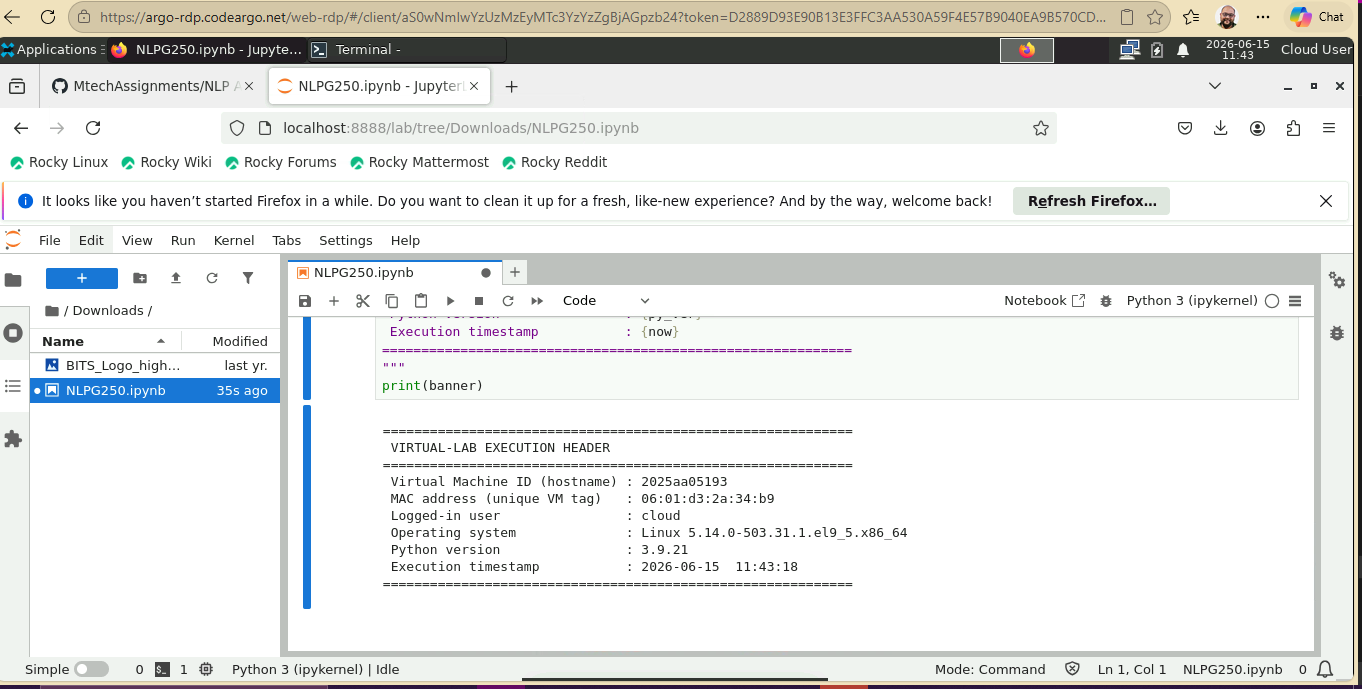

# Appendix 1: Generating Data Set

In [1]:
urls = [
    # ── PROTEIN & MACROS ──────────────────────────────────────────────────────
    "https://www.healthline.com/nutrition/how-much-protein-per-day",
    "https://www.healthline.com/nutrition/10-reasons-to-eat-more-protein",
    "https://www.healthline.com/nutrition/protein-for-vegans-vegetarians",
    "https://www.healthline.com/nutrition/26-muscle-building-foods",
    "https://www.healthline.com/nutrition/high-protein-foods",
    "https://www.healthline.com/nutrition/how-protein-can-help-you-lose-weight",
    "https://www.healthline.com/nutrition/protein-shakes-weight-loss",
    "https://www.healthline.com/nutrition/best-protein-powder",
    "https://www.healthline.com/nutrition/whey-protein-101",
    "https://www.healthline.com/nutrition/casein-protein-is-highly-underrated",

    # ── CALORIES & WEIGHT LOSS ────────────────────────────────────────────────
    "https://www.healthline.com/nutrition/calorie-deficit",
    "https://www.healthline.com/nutrition/how-many-calories-per-day",
    "https://www.healthline.com/nutrition/low-calorie-foods",
    "https://www.healthline.com/nutrition/35-ways-to-cut-calories",
    "https://www.healthline.com/nutrition/counting-calories-101",
    "https://www.healthline.com/nutrition/calories-in-a-pound-of-fat",
    "https://www.healthline.com/nutrition/best-ways-to-burn-fat",
    "https://www.healthline.com/nutrition/weight-loss-for-women",
    "https://www.healthline.com/nutrition/10-graphs-that-show-the-power-of-a-ketogenic-diet",
    "https://www.healthline.com/nutrition/how-to-lose-weight-as-fast-as-possible",

    # ── DIETS ─────────────────────────────────────────────────────────────────
    "https://www.healthline.com/nutrition/best-diet-plans",
    "https://www.healthline.com/nutrition/ketogenic-diet-101",
    "https://www.healthline.com/nutrition/keto-diet-meal-plan-and-menu",
    "https://www.healthline.com/nutrition/low-carb-diet-meal-plan-and-menu",
    "https://www.healthline.com/nutrition/mediterranean-diet-meal-plan",
    "https://www.healthline.com/nutrition/mediterranean-diet-review",
    "https://www.healthline.com/nutrition/paleo-diet-meal-plan-and-menu",
    "https://www.healthline.com/nutrition/vegan-diet-guide",
    "https://www.healthline.com/nutrition/plant-based-diet-guide",
    "https://www.healthline.com/nutrition/whole30",

    # ── INTERMITTENT FASTING ──────────────────────────────────────────────────
    "https://www.healthline.com/nutrition/intermittent-fasting-guide",
    "https://www.healthline.com/nutrition/10-health-benefits-of-intermittent-fasting",
    "https://www.healthline.com/nutrition/6-ways-to-do-intermittent-fasting",
    "https://www.healthline.com/nutrition/intermittent-fasting-and-weight-loss",
    "https://www.healthline.com/nutrition/intermittent-fasting-metabolism",
    "https://www.healthline.com/nutrition/16-8-intermittent-fasting",

    # ── CARBOHYDRATES & SUGAR ─────────────────────────────────────────────────
    "https://www.healthline.com/nutrition/how-many-carbs-per-day-to-lose-weight",
    "https://www.healthline.com/nutrition/good-carbs-bad-carbs",
    "https://www.healthline.com/nutrition/why-refined-carbs-are-bad",
    "https://www.healthline.com/nutrition/15-ways-to-eat-less-sugar",
    "https://www.healthline.com/nutrition/sugar-the-bitter-truth",
    "https://www.healthline.com/nutrition/56-different-names-for-sugar",
    "https://www.healthline.com/nutrition/low-glycemic-diet",
    "https://www.healthline.com/nutrition/fiber-and-weight-loss",
    "https://www.healthline.com/nutrition/22-high-fiber-foods",
    "https://www.healthline.com/nutrition/dietary-fiber-and-blood-sugar",

    # ── FATS & OILS ───────────────────────────────────────────────────────────
    "https://www.healthline.com/nutrition/10-super-healthy-high-fat-foods",
    "https://www.healthline.com/nutrition/healthy-vs-unhealthy-fats",
    "https://www.healthline.com/nutrition/trans-fat-foods",
    "https://www.healthline.com/nutrition/saturated-fat-good-or-bad",
    "https://www.healthline.com/nutrition/omega-3-fatty-acids-guide",
    "https://www.healthline.com/nutrition/6-reasons-why-eggs-are-the-healthiest-food-on-the-planet",
    "https://www.healthline.com/nutrition/coconut-oil-and-weight-loss",
    "https://www.healthline.com/nutrition/extra-virgin-olive-oil",
    "https://www.healthline.com/nutrition/avocado-nutrition",
    "https://www.healthline.com/nutrition/avocado-oil-vs-olive-oil",

    # ── VITAMINS & MINERALS ───────────────────────────────────────────────────
    "https://www.healthline.com/health/food-nutrition/vitamins-to-boost-metabolism",
    "https://www.healthline.com/nutrition/vitamin-d-deficiency-symptoms",
    "https://www.healthline.com/nutrition/vitamin-d-101",
    "https://www.healthline.com/nutrition/magnesium-benefits",
    "https://www.healthline.com/nutrition/magnesium-deficiency-symptoms",
    "https://www.healthline.com/nutrition/zinc",
    "https://www.healthline.com/nutrition/iron-deficiency-anemia",
    "https://www.healthline.com/nutrition/vitamin-b12-benefits",
    "https://www.healthline.com/nutrition/vitamin-c-benefits",
    "https://www.healthline.com/nutrition/best-multivitamins-for-women",

    # ── SUPPLEMENTS ───────────────────────────────────────────────────────────
    "https://www.healthline.com/nutrition/creatine-101",
    "https://www.healthline.com/nutrition/10-benefits-of-creatine",
    "https://www.healthline.com/nutrition/bcaa",
    "https://www.healthline.com/nutrition/pre-workout-supplements",
    "https://www.healthline.com/nutrition/fish-oil-benefits",
    "https://www.healthline.com/nutrition/7-benefits-of-mct-oil",
    "https://www.healthline.com/nutrition/probiotics-101",
    "https://www.healthline.com/nutrition/8-health-benefits-of-probiotics",
    "https://www.healthline.com/nutrition/caffeine-and-exercise",
    "https://www.healthline.com/nutrition/top-10-evidence-based-health-benefits-of-green-tea",

    # ── GUT HEALTH ────────────────────────────────────────────────────────────
    "https://www.healthline.com/nutrition/gut-microbiome-and-health",
    "https://www.healthline.com/nutrition/improve-gut-bacteria",
    "https://www.healthline.com/nutrition/prebiotics-benefits",
    "https://www.healthline.com/nutrition/11-super-healthy-probiotic-foods",
    "https://www.healthline.com/nutrition/fermented-foods",
    "https://www.healthline.com/nutrition/leaky-gut-syndrome",

    # ── HYDRATION ─────────────────────────────────────────────────────────────
    "https://www.healthline.com/nutrition/how-much-water-should-you-drink-per-day",
    "https://www.healthline.com/nutrition/7-health-benefits-of-water",
    "https://www.healthline.com/nutrition/electrolytes",
    "https://www.healthline.com/nutrition/sports-drinks",
    "https://www.healthline.com/nutrition/coconut-water-benefits",

    # ── SUPERFOODS & SPECIFIC FOODS ───────────────────────────────────────────
    "https://www.healthline.com/nutrition/20-nutrition-facts-that-should-be-common-sense",
    "https://www.healthline.com/nutrition/27-health-and-nutrition-tips",
    "https://www.healthline.com/nutrition/healthy-eating-tips",
    "https://www.healthline.com/nutrition/how-to-eat-healthy-guide",
    "https://www.healthline.com/nutrition/11-most-nutrient-dense-foods-on-the-planet",
    "https://www.healthline.com/nutrition/true-superfoods",
    "https://www.healthline.com/nutrition/14-healthiest-vegetables-on-earth",
    "https://www.healthline.com/nutrition/20-healthiest-fruits",
    "https://www.healthline.com/nutrition/11-proven-benefits-of-bananas",
    "https://www.healthline.com/nutrition/10-proven-benefits-of-blueberries",
    "https://www.healthline.com/nutrition/foods-high-in-antioxidants",
    "https://www.healthline.com/nutrition/8-benefits-of-nuts",
    "https://www.healthline.com/nutrition/9-proven-benefits-of-almonds",
    "https://www.healthline.com/nutrition/12-proven-benefits-of-avocado",
    "https://www.healthline.com/nutrition/10-proven-health-benefits-of-eggs",
    "https://www.healthline.com/nutrition/10-health-benefits-of-salmon",
    "https://www.healthline.com/nutrition/foods-high-in-vitamin-c",
    "https://www.healthline.com/nutrition/10-benefits-of-honey",
    "https://www.healthline.com/nutrition/benefits-of-sweet-potatoes",
    "https://www.healthline.com/nutrition/is-chicken-good-for-you",

    # ── MEAL PLANNING & EATING HABITS ─────────────────────────────────────────
    "https://www.healthline.com/nutrition/meal-prep",
    "https://www.healthline.com/nutrition/how-to-meal-prep",
    "https://www.healthline.com/nutrition/meal-planning-tips",
    "https://www.healthline.com/nutrition/healthy-low-fat-foods",
    "https://www.healthline.com/nutrition/healthy-eating-for-beginners",
    "https://www.healthline.com/nutrition/mindful-eating-guide",
    "https://www.healthline.com/nutrition/how-to-stop-overeating",
    "https://www.healthline.com/nutrition/13-tips-to-stop-sugar-cravings",
    "https://www.healthline.com/nutrition/19-ways-to-eat-healthy-on-a-budget",
    "https://www.healthline.com/nutrition/portion-control",

    # ── METABOLISM & ENERGY ───────────────────────────────────────────────────
    "https://www.healthline.com/nutrition/10-ways-to-boost-metabolism",
    "https://www.healthline.com/nutrition/metabolism-boosting-foods",
    "https://www.healthline.com/nutrition/what-is-metabolism",
    "https://www.healthline.com/nutrition/how-to-increase-energy",
    "https://www.healthline.com/nutrition/best-foods-for-energy",
    "https://www.healthline.com/nutrition/caffeine-and-exercise",
    "https://www.healthline.com/nutrition/does-coffee-boost-metabolism",

    # ── EXERCISE & FITNESS ────────────────────────────────────────────────────
    "https://www.healthline.com/nutrition/10-benefits-of-exercise",
    "https://www.healthline.com/health/fitness/benefits-of-exercise",
    "https://www.healthline.com/health/exercise-fitness/how-to-start-working-out",
    "https://www.healthline.com/health/fitness-exercise/cardio-exercises-list",
    "https://www.healthline.com/health/exercise-fitness/hiit-workouts-for-beginners",
    "https://www.healthline.com/health/fitness/hiit",
    "https://www.healthline.com/health/fitness/strength-training-at-home",
    "https://www.healthline.com/health/fitness/benefits-of-strength-training",
    "https://www.healthline.com/health/exercise-fitness/how-to-build-endurance",
    "https://www.healthline.com/health/how-many-steps-a-day",
    "https://www.healthline.com/health/walking-for-weight-loss",
    "https://www.healthline.com/health/exercise-fitness/running-everyday",
    "https://www.healthline.com/health/exercise-fitness/how-many-calories-do-i-burn-a-day",
    "https://www.healthline.com/health/fitness/calories-burned-lifting-weights",
    "https://www.healthline.com/health/exercise-fitness/yoga-for-weight-loss",

    # ── MUSCLE BUILDING & BODY COMPOSITION ───────────────────────────────────
    "https://www.healthline.com/nutrition/how-to-build-muscle",
    "https://www.healthline.com/health/how-long-does-it-take-to-build-muscle",
    "https://www.healthline.com/nutrition/eat-after-workout",
    "https://www.healthline.com/nutrition/eat-before-workout",
    "https://www.healthline.com/nutrition/bodybuilding-meal-plan",
    "https://www.healthline.com/health/how-to-increase-stamina",
    "https://www.healthline.com/health/muscle-recovery",
    "https://www.healthline.com/health/exercise-fitness/delayed-onset-muscle-soreness",

    # ── WEIGHT MANAGEMENT ─────────────────────────────────────────────────────
    "https://www.healthline.com/nutrition/30-ways-to-lose-weight-naturally",
    "https://www.healthline.com/nutrition/weight-loss-plateau",
    "https://www.healthline.com/nutrition/does-exercise-cause-weight-loss",
    "https://www.healthline.com/nutrition/body-fat-percentage",
    "https://www.healthline.com/nutrition/bmi-calculation",
    "https://www.healthline.com/nutrition/obesity",

    # ── SLEEP & RECOVERY ──────────────────────────────────────────────────────
    "https://www.healthline.com/nutrition/sleep-and-weight-loss",
    "https://www.healthline.com/health/sleep-deprivation/effects-on-body",
    "https://www.healthline.com/nutrition/17-tips-to-sleep-better",
    "https://www.healthline.com/nutrition/10-reasons-why-good-sleep-is-important",
    "https://www.healthline.com/health/food-nutrition/foods-that-help-you-sleep",

    # ── BLOOD SUGAR & DIABETES ────────────────────────────────────────────────
    "https://www.healthline.com/nutrition/15-ways-to-lower-blood-sugar",
    "https://www.healthline.com/health/type-2-diabetes/best-meal-plans",
    "https://www.healthline.com/nutrition/blood-sugar-spikes",
    "https://www.healthline.com/nutrition/insulin-and-insulin-resistance",
    "https://www.healthline.com/nutrition/sugar-and-diabetes",

    # ── HEART HEALTH ──────────────────────────────────────────────────────────
    "https://www.healthline.com/nutrition/heart-healthy-foods",
    "https://www.healthline.com/nutrition/17-best-foods-to-lower-blood-pressure",
    "https://www.healthline.com/nutrition/low-sodium-diet",
    "https://www.healthline.com/nutrition/how-to-lower-cholesterol",
    "https://www.healthline.com/nutrition/dietary-cholesterol-does-not-matter",

    # ── GUT MICROBIOME & DIGESTION ────────────────────────────────────────────
    "https://www.healthline.com/nutrition/ways-to-improve-digestion",
    "https://www.healthline.com/health/digestive-health/things-that-mess-with-gut",
    "https://www.healthline.com/nutrition/11-proven-health-benefits-of-garlic",
    "https://www.healthline.com/nutrition/9-benefits-oats-oatmeal",
    "https://www.healthline.com/nutrition/is-greek-yogurt-good-for-you",

    # ── HORMONES & INFLAMMATION ───────────────────────────────────────────────
    "https://www.healthline.com/nutrition/anti-inflammatory-diet-101",
    "https://www.healthline.com/nutrition/13-anti-inflammatory-foods",
    "https://www.healthline.com/nutrition/cortisol-and-weight-gain",
    "https://www.healthline.com/nutrition/balance-hormones",
    "https://www.healthline.com/health/testosterone-and-working-out",

    # ── MENTAL HEALTH & DIET ──────────────────────────────────────────────────
    "https://www.healthline.com/nutrition/mood-food",
    "https://www.healthline.com/nutrition/brain-food",
    "https://www.healthline.com/nutrition/foods-for-brain-health",
    "https://www.healthline.com/nutrition/stress-eating",
    "https://www.healthline.com/nutrition/emotional-eating",

    # ── SPECIFIC DIETS & LIFESTYLES ───────────────────────────────────────────
    "https://www.healthline.com/nutrition/vegan-vs-vegetarian",
    "https://www.healthline.com/nutrition/carnivore-diet",
    "https://www.healthline.com/nutrition/gluten-free-diet",
    "https://www.healthline.com/nutrition/dash-diet",
    "https://www.healthline.com/nutrition/13-ways-sugary-soda-is-bad-for-you",
    "https://www.healthline.com/nutrition/why-is-junk-food-bad",
    "https://www.healthline.com/nutrition/20-most-weight-loss-friendly-foods",
    "https://www.healthline.com/nutrition/clean-eating",

    # ── SPECIFIC POPULATIONS ──────────────────────────────────────────────────
    "https://www.healthline.com/nutrition/nutrition-for-runners",
    "https://www.healthline.com/nutrition/best-diet-for-athletes",
    "https://www.healthline.com/nutrition/vegetarian-athlete",
    "https://www.healthline.com/nutrition/eating-healthy-on-vacation",
    "https://www.healthline.com/nutrition/how-to-gain-weight",
    "https://www.healthline.com/nutrition/10-ways-to-gain-weight",
    "https://www.healthline.com/nutrition/best-foods-to-eat-pregnant",
    "https://www.healthline.com/nutrition/healthy-eating-for-kids",
    "https://www.healthline.com/nutrition/senior-nutrition",
    "https://www.healthline.com/nutrition/diet-for-men",
]

print(f"Total URLs: {len(urls)}")

Total URLs: 201


In [2]:
print(f"Total URLs    : {len(urls)}")
print(f"Unique URLs   : {len(set(urls))}")
print(f"Duplicates    : {len(urls) - len(set(urls))}")

# Group by topic for a clean overview
topics = {}
for url in urls:
    slug = url.replace("https://www.healthline.com/nutrition/","").replace("https://www.healthline.com/health/","")
    prefix = slug.split("-")[0]
    topics.setdefault(prefix, []).append(url)

print(f"\nTopic groups  : {len(topics)}")

Total URLs    : 201
Unique URLs   : 200
Duplicates    : 1

Topic groups  : 117


In [4]:
from requests_html import HTMLSession
import time
import pandas as pd
session = HTMLSession()

def scrape_healthline(url):
    r = session.get(url)
    
    # Healthline puts article body inside these containers
    # Try each selector in order until one works
    selectors = [
        "article",                  # fallback — all <p> inside <main>
    ]
    
    paragraphs = []
    for selector in selectors:
        elements = r.html.find(selector)
        if elements:
            # grab all <p> tags inside the matched container
            for el in elements:
                paragraphs.extend(el.find("p"))
            break
    
    # If nothing matched, fall back to all <p>
    if not paragraphs:
        paragraphs = r.html.find("p")
    
    title = r.html.find("h1", first=True)
    title = title.text if title else "N/A"
    
    text = " ".join(
        p.text for p in paragraphs
    )
    
    return {"title": title, "url": url, "articletext": text}

records = []

for url in urls:
    print(f"Scraping: {url}")
    result = scrape_healthline(url)
    if result:
        records.append(result)
        print(f"  ✔ '{result['title'][:50]}' — '{result['url']}'")
    time.sleep(2)

df = pd.DataFrame(records)
df.to_csv("fitness_blog_dataset.csv", index=False)
print(f"\n✅ Saved {len(df)} articles to fitness_blog_dataset.csv")
print(df[["title", "url", "articletext"[:50]]])


Scraping: https://www.healthline.com/nutrition/how-much-protein-per-day
  ✔ 'Protein Intake — How Much Protein Should You Eat P' — 'https://www.healthline.com/nutrition/how-much-protein-per-day'
Scraping: https://www.healthline.com/nutrition/10-reasons-to-eat-more-protein
  ✔ '10 Science-Backed Reasons to Eat More Protein' — 'https://www.healthline.com/nutrition/10-reasons-to-eat-more-protein'
Scraping: https://www.healthline.com/nutrition/protein-for-vegans-vegetarians
  ✔ 'The Best Vegan and Vegetarian Sources of Protein' — 'https://www.healthline.com/nutrition/protein-for-vegans-vegetarians'
Scraping: https://www.healthline.com/nutrition/26-muscle-building-foods
  ✔ '26 Foods to Eat to Gain Muscle' — 'https://www.healthline.com/nutrition/26-muscle-building-foods'
Scraping: https://www.healthline.com/nutrition/high-protein-foods
  ✔ '16 Delicious High Protein Foods' — 'https://www.healthline.com/nutrition/high-protein-foods'
Scraping: https://www.healthline.com/nutrition/how-protein-